### WJI Panel A

In [1]:
import pandas as pd

seeds = [42,0,1,2,3]
cancers = ["ccRCC", "Melanoma","NSCLC"]
algo = ["Avatars K5", "Avatars K10", "CTGAN", "Gaussian Copula", "Synthpop"]
Cancer_dict = {}
for cancer in cancers:
    score_dict = {}
    print(cancer)
    for seed in seeds:
        if cancer == 'ccRCC':
            wji_seed = pd.read_csv(f"../ccRCC/NarrowUtility/CellDecovo/ResultsDA_cibersortx/Seed_{seed}/WeightedJaccardIndex_{seed}.csv")
            algo = ["Avatars K5", "Avatars K10", "CTGAN", "Gaussian Copula", "Synthpop"]
        if cancer == 'Melanoma':
            wji_seed = pd.read_csv(f"../Melanoma/NarrowUtility/CellDecovo/ResultsDA/Seed_{seed}/WeightedJaccardIndex_{seed}.csv")
            algo = ["Avatars K5", "Avatars K10", "CTGAN", "Gaussian Copula", "Synthpop", 'TVAE']
        if cancer == 'NSCLC':
            wji_seed = pd.read_csv(f"../NSCLC/NarrowUtility/CellDeco/ResultsDA_cibersortx/Seed_{seed}/WeightedJaccardIndex_{seed}.csv")
            algo = ["Avatars K5", "Avatars K10", "CTGAN", "Gaussian Copula", "Synthpop", "TVAE"]
        scores = wji_seed['SFS'].values.tolist()
        score_dict[seed] = scores
    df_cancer = pd.DataFrame(score_dict, index = algo).T
    Cancer_dict[cancer] = df_cancer

ccRCC
Melanoma
NSCLC


In [2]:
Cancer_dict['ccRCC']

,Avatars K5,Avatars K10,CTGAN,Gaussian Copula,Synthpop
42,0.267268,0.508413,-0.000000,0.068680,0.008609
0,0.377463,0.108793,0.091018,0.345811,0.132992
1,0.330110,0.378792,0.076271,1.075824,-0.000000
2,0.321438,0.107061,0.081020,0.591950,0.007753
3,0.645380,0.319489,0.083044,0.214706,0.114732


In [4]:
from typing import Dict, Optional, Tuple, Union, List, Sequence
import itertools
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

# Consistent color definitions for manuscript-quality figures
# Reuse these variables across plotting functions to ensure consistent visual identity.
METHOD_COLOR_SCHEME = {
    "palette_name": "Set2",
    # A default Set2-like palette defined explicitly as hex colors so it's stable across environments.
    "palette": [
        "#66c2a5",  # greenish
        "#fc8d62",  # orange
        "#8da0cb",  # blue
        "#e78ac3",  # pink
        "#a6d854",  # lime
        "#ffd92f",  # yellow
        "#e5c494",  # tan
        "#b3b3b3",  # grey
    ],
}

# Cancer-type colors (fixed identity across the manuscript)
# Chosen to be colorblind-friendly-ish and visually distinct.
CANCER_COLORS = {
    "ccRCC": "#4C72B0",     # blue
    "Melanoma": "#DD8452",  # orange
    "NSCLC": "#55A868",     # green
}

# Font preference for Nature-style figures (Helvetica if available, otherwise Arial/DejaVu Sans fallback)
NATURE_FONT = {
    "family": "sans-serif",
    "sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
}

# Colors for stability/benchmark plots (aligned with METHOD_COLOR_SCHEME)
STABILITY_PLOT_COLORS = {
    "median": "#000000",
    "swarm": "#000000",
    "mean_edge": "#b2182b",   # dark red
    "mean_face": "#ffffff",   # white
    "grid": "#e6e6e6",
    "heatmap_bg": "#f7f7f7",
    'grid': "#e6e6e6",
    "missing_edge": "#BDBDBD",
    "missing_face": "#FFFFFF"
}

# Reuse dataset colors from this module for consistency (methods/algorithms identity)
DATASET_COLORS = {
    "Avatars K5": "#66c2a5",         # greenish
    "Avatars K10": "#fc8d62",        # orange
    "CTGAN": "#8da0cb",              # blue
    "Gaussian Copula": "#e78ac3",    # pink
    "Synthpop": "#a6d854",           # lime
    "TVAE": "#ffd92f",               # yellow
}

# Heatmap: emphasize only whether P(Better) exceeds 0.5
PBETTER_FOCUS_CMAP = LinearSegmentedColormap.from_list(
    "pbetter_focus",
    [
        (0.0, "#ffffff"),
        (0.5, "#ffffff"),
        (1.0, "#1a9850"),
    ],
)


def _build_method_palette(methods: Sequence[str], palette: Union[str, list]) -> Dict[str, str]:
    """
    Build a stable categorical palette mapping method -> color.

    Args:
        methods (Sequence[str]): Method names in the desired order.
        palette (Union[str, list]): Seaborn palette name or a list of colors.

    Returns:
        Dict[str, str]: Mapping from method name to hex/RGB color.

    Raises:
        ValueError: If methods is empty.
    """
    if not methods:
        raise ValueError("methods must be a non-empty sequence.")

    n = len(methods)

    if isinstance(palette, (list, tuple)) and len(palette) >= n:
        pal = list(palette)
    elif isinstance(palette, str):
        try:
            pal = list(sns.color_palette(palette, n_colors=n))
        except Exception:
            pal = METHOD_COLOR_SCHEME["palette"][:n]
    else:
        pal = METHOD_COLOR_SCHEME["palette"][:n]

    return {methods[i]: pal[i % len(pal)] for i in range(n)}


def _set_nature_rcparams(fontsize: int = 11) -> None:
    """
    Apply Nature-like matplotlib rcParams (Helvetica/Arial and clean axes).

    Args:
        fontsize (int): Base font size for the figure.
    """
    plt.rcParams.update(
        {
            "font.size": fontsize,
            "font.family": NATURE_FONT["family"],
            "font.sans-serif": NATURE_FONT["sans-serif"],
            "pdf.fonttype": 42,  # embed TrueType fonts (Illustrator-friendly)
            "ps.fonttype": 42,
            "axes.titlesize": fontsize + 1,
            "axes.labelsize": fontsize,
            "xtick.labelsize": fontsize - 1,
            "ytick.labelsize": fontsize - 1,
            "legend.fontsize": fontsize - 1,
        }
    )


def plot_boxplot_grid_by_cancer(
    cancer_to_method_scores: Dict[str, Dict[str, List[float]]],
    value_name: str = "Score",
    methods_order: Optional[Sequence[str]] = None,
    palette: Optional[Dict[str, str]] = None,
    figsize: Tuple[int, int] = (18, 5),
    fontsize: int = 11,
    annotate_mean: bool = True,
    mean_fmt: str = "{:.3f}",
    mean_marker: str = "D",
    mean_marker_size: float = 70.0,
    mean_text_offset_frac: float = 0.03,
    sharey: bool = True,
    show: bool = True,
) -> Tuple[plt.Figure, np.ndarray, Dict[str, pd.Series]]:
    """
    Plot a 1xN grid of violin plots, one per cancer type, using a shared method color palette.
    The mean of each method is shown as a white diamond and optionally annotated as text.

    Args:
        cancer_to_method_scores (Dict[str, Dict[str, List[float]]]): Mapping cancer -> {method -> list of scores}.
        value_name (str): Y-axis label for the score metric.
        methods_order (Optional[Sequence[str]]): Global ordering of methods across all panels.
            If None, uses the union of methods in insertion order.
        palette (Optional[Dict[str, str]]): Mapping method -> color. If None, uses DATASET_COLORS.
        figsize (Tuple[int, int]): Figure size.
        fontsize (int): Base font size.
        annotate_mean (bool): If True, write the mean value above each violin.
        mean_fmt (str): Format string for the mean annotation (e.g., "{:.3f}").
        mean_marker (str): Marker for mean point.
        mean_marker_size (float): Marker size for mean point.
        mean_text_offset_frac (float): Vertical offset for mean text as a fraction of y-span.
        sharey (bool): If True, share y-axis across panels.
        show (bool): If True, calls plt.show().

    Returns:
        Tuple[plt.Figure, np.ndarray, Dict[str, pd.Series]]: (figure, axes, mean_by_cancer).

    Raises:
        ValueError: If cancer_to_method_scores is empty.
        ValueError: If any cancer has no methods or no numeric scores after cleaning.
        ValueError: If methods_order contains methods missing from all cancers.
    """
    if not cancer_to_method_scores:
        raise ValueError("cancer_to_method_scores must be a non-empty dictionary.")

    cancers = list(cancer_to_method_scores.keys())

    # Determine global method order
    if methods_order is None:
        union_methods: List[str] = []
        for cancer in cancers:
            for m in list(cancer_to_method_scores.get(cancer, {}).keys()):
                if m not in union_methods:
                    union_methods.append(m)
        methods_order = union_methods
    else:
        methods_order = list(methods_order)

    if len(methods_order) == 0:
        raise ValueError("methods_order resolved to an empty list.")

    # Palette: default to DATASET_COLORS (requested) and ensure all needed methods exist
    if palette is None:
        palette = dict(DATASET_COLORS)

    pal_map = {m: palette.get(m, "#333333") for m in methods_order}

    _set_nature_rcparams(fontsize=fontsize)
    sns.set_style("whitegrid", rc={"grid.color": STABILITY_PLOT_COLORS["grid"]})

    n = len(cancers)
    fig, axes = plt.subplots(1, n, figsize=figsize, sharey=sharey)
    if n == 1:
        axes = np.array([axes])

    mean_by_cancer: Dict[str, pd.Series] = {}

    for ax, cancer in zip(axes, cancers):
        method_scores = cancer_to_method_scores.get(cancer, {})
        if method_scores is None or len(method_scores) == 0:
            raise ValueError(f"Cancer '{cancer}' has no method scores.")

        # Build long df
        rows = []
        for m in methods_order:
            vals = method_scores.get(m, None)
            if vals is None:
                continue
            arr = pd.to_numeric(pd.Series(vals), errors="coerce").dropna().to_numpy(dtype=float)
            for v in arr:
                rows.append({"Method": m, value_name: float(v)})

        df_long = pd.DataFrame(rows)
        if df_long.empty:
            raise ValueError(f"Cancer '{cancer}' has no valid numeric scores after cleaning.")

        df_long["Method"] = pd.Categorical(df_long["Method"], categories=list(methods_order), ordered=True)

        sns.boxplot(
            data=df_long,
            x="Method",
            y=value_name,
            order=list(methods_order),
            palette=pal_map,
            # cut=0,
            # inner="quartile",
            linewidth=1.2,
            ax=ax,
        )

        # Means
        mean_by_method = df_long.groupby("Method")[value_name].mean().reindex(list(methods_order))
        mean_by_cancer[cancer] = mean_by_method

        y_min, y_max = ax.get_ylim()
        y_span = (y_max - y_min) if (y_max > y_min) else 1.0

        for i, m in enumerate(list(methods_order)):
            mu = mean_by_method.loc[m]
            if pd.isna(mu):
                continue

            ax.scatter(
                i,
                float(mu),
                marker=mean_marker,
                s=mean_marker_size,
                facecolor=STABILITY_PLOT_COLORS["mean_face"],
                edgecolor=STABILITY_PLOT_COLORS["mean_edge"],
                linewidth=1.3,
                zorder=10,
            )

            if annotate_mean:
                ax.text(
                    i,
                    float(mu) + float(mean_text_offset_frac) * y_span,
                    mean_fmt.format(float(mu)),
                    ha="center",
                    va="bottom",
                    fontsize=fontsize - 2,
                    color="black",
                )

        ax.set_xlabel("")
        if ax is axes[0]:
            ax.set_ylabel(value_name, fontsize=fontsize)
        else:
            ax.set_ylabel("")

        ax.tick_params(axis="x", rotation=45)
        for lbl in ax.get_xticklabels():
            lbl.set_fontweight("bold")

        # Cancer label + a small colored strip for consistent cancer identity
        cancer_color = CANCER_COLORS.get(cancer, "#333333")
        ax.set_title(cancer, fontsize=fontsize + 1, fontweight="bold", color="black", pad=10)
        ax.plot([0.02, 0.98], [1.02, 1.02], transform=ax.transAxes, color=cancer_color, lw=4, clip_on=False)

    plt.tight_layout()
    if show:
        plt.show()

    return fig, axes, mean_by_cancer

/tmp/ipykernel_1109633/2226866363.py:229: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1109633/2226866363.py:242: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_by_method = df_long.groupby("Method")[value_name].mean().reindex(list(methods_order))
/tmp/ipykernel_1109633/2226866363.py:229: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1109633/2226866363.py:242: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version 

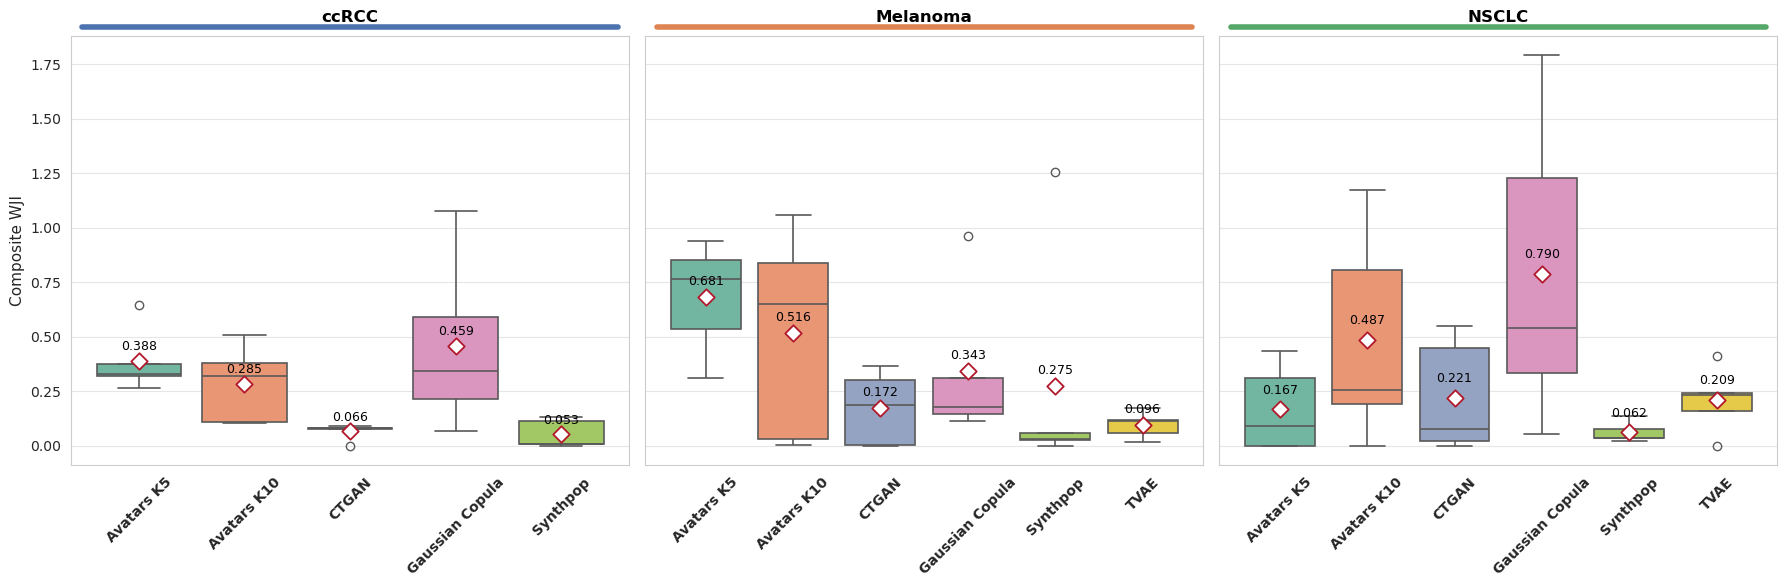

In [5]:
fig_a, axes, mean_by_cancer = plot_boxplot_grid_by_cancer(
    cancer_to_method_scores=Cancer_dict,
    value_name="Composite WJI",  
    methods_order=algo, 
    palette=DATASET_COLORS, 
    figsize=(18, 6),         
    fontsize=11,
    annotate_mean=True,    
    show=True,
)

fig_a.savefig("panelA_Cibersortx.png", dpi=300, bbox_inches="tight", facecolor="white")
fig_a.savefig("panelA_Cibersortx.pdf", bbox_inches="tight", facecolor="white")

In [6]:
from __future__ import annotations

from typing import Dict, List, Optional, Sequence, Tuple, Union

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

try:
    import baycomp
except ImportError as e:
    raise ImportError("baycomp is required. Install with: pip install baycomp") from e

from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap


def _set_nature_rcparams(fontsize: int = 11) -> None:
    """
    Apply Nature-like matplotlib rcParams (Helvetica/Arial and clean axes).

    Args:
        fontsize (int): Base font size for the figure.

    Raises:
        ValueError: If fontsize is not positive.
    """
    if fontsize <= 0:
        raise ValueError("fontsize must be a positive integer.")

    plt.rcParams.update(
        {
            "font.size": fontsize,
            "font.family": NATURE_FONT["family"],
            "font.sans-serif": NATURE_FONT["sans-serif"],
            "pdf.fonttype": 42,
            "ps.fonttype": 42,
            "axes.titlesize": fontsize + 1,
            "axes.labelsize": fontsize,
            "xtick.labelsize": fontsize - 1,
            "ytick.labelsize": fontsize - 1,
            "legend.fontsize": fontsize - 1,
        }
    )


def _overlay_hatched_missing_cells(
    ax: plt.Axes,
    mat: pd.DataFrame,
    hatch: str = "///",
    edgecolor: str = "#BDBDBD",
    facecolor: str = "#FFFFFF",
    linewidth: float = 0.6,
) -> None:
    """
    Overlay hatched rectangles on NaN cells in a seaborn heatmap.

    Args:
        ax (plt.Axes): Axis containing the heatmap.
        mat (pd.DataFrame): Heatmap matrix (NaNs indicate missing cells).
        hatch (str): Matplotlib hatch pattern.
        edgecolor (str): Rectangle edge color.
        facecolor (str): Rectangle face color.
        linewidth (float): Rectangle edge line width.

    Returns:
        None
    """
    nrows, ncols = mat.shape
    nan_mask = mat.isna().to_numpy()

    # Heatmap uses data coords where each cell is 1x1 square; origin is top-left.
    for i in range(nrows):
        for j in range(ncols):
            if not nan_mask[i, j]:
                continue
            rect = mpatches.Rectangle(
                (j, i),  # (x, y)
                1.0,
                1.0,
                facecolor=facecolor,
                edgecolor=edgecolor,
                hatch=hatch,
                linewidth=linewidth,
                fill=True,
                zorder=10,
            )
            ax.add_patch(rect)


def build_baycomp_comparison_df(
    method_to_scores: Union[Dict[str, Sequence[float]], pd.DataFrame],
    methods_order: Optional[Sequence[str]] = None,
    rope: float = 0.01,
) -> pd.DataFrame:
    """
    Compute pairwise Bayesian comparison probabilities (better/worse/equivalent)
    using baycomp.two_on_single for all ordered pairs of methods.

    Args:
        method_to_scores (Union[Dict[str, Sequence[float]], pd.DataFrame]):
            Either a dict mapping method -> list/array of scores across seeds,
            or a wide DataFrame with columns=methods and rows=seeds.
        methods_order (Optional[Sequence[str]]): Optional method ordering. If None, uses dict keys / DataFrame columns.
        rope (float): ROPE threshold for practical equivalence.

    Returns:
        pd.DataFrame: Comparison table with columns:
            ["Method 1", "Method 2", "Better Prob", "Worse Prob", "Equivalent Prob"].

    Raises:
        ValueError: If rope is not positive.
        ValueError: If fewer than 2 methods remain after filtering.
        ValueError: If any present method has fewer than 2 finite scores.
        TypeError: If method_to_scores has unsupported type.
    """
    if rope <= 0:
        raise ValueError("rope must be > 0.")

    if isinstance(method_to_scores, pd.DataFrame):
        if method_to_scores.empty:
            raise ValueError("method_to_scores DataFrame must be non-empty.")
        method_to_scores_dict: Dict[str, Sequence[float]] = method_to_scores.to_dict(orient="list")
    elif isinstance(method_to_scores, dict):
        if len(method_to_scores) == 0:
            raise ValueError("method_to_scores must be a non-empty dictionary.")
        method_to_scores_dict = method_to_scores
    else:
        raise TypeError("method_to_scores must be a dict or a pandas DataFrame.")

    if methods_order is None:
        methods_order = list(method_to_scores_dict.keys())
    else:
        methods_order = list(methods_order)

    scores_np: Dict[str, np.ndarray] = {}
    for m in methods_order:
        if m not in method_to_scores_dict:
            continue
        x = np.asarray(method_to_scores_dict[m], dtype=float)
        x = x[np.isfinite(x)]
        if x.size < 2:
            raise ValueError(f"Method '{m}' must have at least 2 finite scores for baycomp.")
        scores_np[m] = x

    if len(scores_np) < 2:
        raise ValueError("Fewer than 2 methods remain after filtering missing methods / invalid scores.")

    present_methods = [m for m in methods_order if m in scores_np]

    rows: List[dict] = []
    for m1 in present_methods:
        for m2 in present_methods:
            if m1 == m2:
                continue
            probs = baycomp.two_on_single(scores_np[m1], scores_np[m2], rope=rope, plot=False)
            rows.append(
                {
                    "Method 1": m1,
                    "Method 2": m2,
                    "Better Prob": float(probs[0]),
                    "Worse Prob": float(probs[2]),
                    "Equivalent Prob": float(probs[1]),
                }
            )

    return pd.DataFrame(rows)


def plot_pbetter_heatmap_grid(
    cancer_to_method_scores: Dict[str, Dict[str, Sequence[float]]],
    cancers_order: Sequence[str] = ("ccRCC", "Melanoma", "NSCLC"),
    methods_order: Optional[Sequence[str]] = None,
    rope: float = 0.01,
    value_col: str = "Better Prob",
    figsize: Tuple[int, int] = (18, 5.5),
    annot: bool = True,
    fmt: str = ".2f",
    fontsize: int = 11,
    missing_hatch: str = "///",
    show: bool = True,
) -> Tuple[plt.Figure, np.ndarray, Dict[str, pd.DataFrame], Dict[str, pd.DataFrame]]:
    """
    Plot a 1x3 grid of P(Better) heatmaps (one per cancer), computed from baycomp comparisons.

    Edge-case behavior:
    - If a method is missing for a given cancer, cells in its row/column remain NaN.
    - NaN cells are displayed as hatched (striped) boxes rather than a solid gray fill.

    Args:
        cancer_to_method_scores (Dict[str, Dict[str, Sequence[float]]]): Mapping cancer -> {method -> scores across seeds}.
        cancers_order (Sequence[str]): Order of cancers in the grid.
        methods_order (Optional[Sequence[str]]): Global method ordering. If None, uses union over cancers.
        rope (float): ROPE for equivalence.
        value_col (str): Which probability to visualize: "Better Prob", "Worse Prob", or "Equivalent Prob".
        figsize (Tuple[int, int]): Figure size.
        annot (bool): If True, annotate cells (NaN cells will be blank).
        fmt (str): Annotation format.
        fontsize (int): Base font size.
        missing_hatch (str): Hatch pattern for missing (NaN) cells.
        show (bool): If True, calls plt.show().

    Returns:
        Tuple[plt.Figure, np.ndarray, Dict[str, pd.DataFrame], Dict[str, pd.DataFrame]]:
            fig, axes, matrices_by_cancer, comparison_dfs_by_cancer

    Raises:
        ValueError: If cancers_order includes a cancer missing from input.
        ValueError: If value_col is invalid.
        ValueError: If methods_order resolves to empty.
    """
    allowed = {"Better Prob", "Worse Prob", "Equivalent Prob"}
    if value_col not in allowed:
        raise ValueError(f"value_col must be one of {sorted(allowed)}.")

    cancers_order = list(cancers_order)
    for c in cancers_order:
        if c not in cancer_to_method_scores:
            raise ValueError(f"Cancer '{c}' missing from cancer_to_method_scores.")

    if methods_order is None:
        union_methods: List[str] = []
        for c in cancers_order:
            for m in list(cancer_to_method_scores[c].keys()):
                if m not in union_methods:
                    union_methods.append(m)
        methods_order = union_methods
    else:
        methods_order = list(methods_order)

    if len(methods_order) == 0:
        raise ValueError("methods_order resolved to an empty list.")

    _set_nature_rcparams(fontsize=fontsize)
    sns.set(style="white", rc={"axes.facecolor": STABILITY_PLOT_COLORS["heatmap_bg"]})

    fig, axes = plt.subplots(1, len(cancers_order), figsize=figsize)
    if len(cancers_order) == 1:
        axes = np.array([axes])

    norm = TwoSlopeNorm(vmin=0.0, vcenter=0.5, vmax=1.0)
    cmap = PBETTER_FOCUS_CMAP if value_col == "Better Prob" else plt.get_cmap("viridis")

    matrices_by_cancer: Dict[str, pd.DataFrame] = {}
    comparison_by_cancer: Dict[str, pd.DataFrame] = {}

    for ax, cancer in zip(axes, cancers_order):
        present_methods = set(cancer_to_method_scores[cancer].keys())

        comp_df = build_baycomp_comparison_df(
            method_to_scores=cancer_to_method_scores[cancer],
            methods_order=methods_order,
            rope=rope,
        )
        comparison_by_cancer[cancer] = comp_df

        # Full matrix initialized to NaN (missing methods remain NaN)
        mat = pd.DataFrame(index=list(methods_order), columns=list(methods_order), dtype=float)

        if not comp_df.empty:
            mat_present = comp_df.pivot(index="Method 1", columns="Method 2", values=value_col)
            mat.loc[mat_present.index, mat_present.columns] = mat_present

        # Diagonal: set 0.5 only if method exists for this cancer
        for m in methods_order:
            if m in present_methods:
                mat.loc[m, m] = 0.5

        matrices_by_cancer[cancer] = mat

        # Important: draw NaNs as white (we will overlay hatch ourselves)
        # Use mask so seaborn doesn't try to color them; hatch overlay will show missing explicitly.
        mask = mat.isna()

        sns.heatmap(
            mat,
            ax=ax,
            cmap=cmap,
            norm=norm if value_col == "Better Prob" else None,
            mask=mask,  # <-- do not draw NaN cells here
            annot=annot,
            fmt=fmt,
            linewidths=0.5,
            linecolor="lightgray",
            cbar=(ax is axes[-1]),
            cbar_kws={"label": value_col} if (ax is axes[-1]) else None,
            square=True,
        )

        # Overlay hatch where NaN
        _overlay_hatched_missing_cells(
            ax=ax,
            mat=mat,
            hatch=missing_hatch,
            edgecolor=STABILITY_PLOT_COLORS["missing_edge"],
            facecolor=STABILITY_PLOT_COLORS["missing_face"],
            linewidth=0.6,
        )

        ax.set_title(cancer, fontsize=fontsize + 1, fontweight="bold", pad=10)

        # Colored strip under title
        cancer_color = CANCER_COLORS.get(cancer, "#333333")
        ax.plot([0.02, 0.98], [1.02, 1.02], transform=ax.transAxes, color=cancer_color, lw=4, clip_on=False)

        ax.set_xlabel("Method 2", fontsize=fontsize)
        ax.set_ylabel("Method 1", fontsize=fontsize)
        # ax.tick_params(axis="x", rotation=45)
        plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')
        ax.tick_params(axis="y", rotation=0)

    plt.tight_layout()
    if show:
        plt.show()

    return fig, axes, matrices_by_cancer, comparison_by_cancer

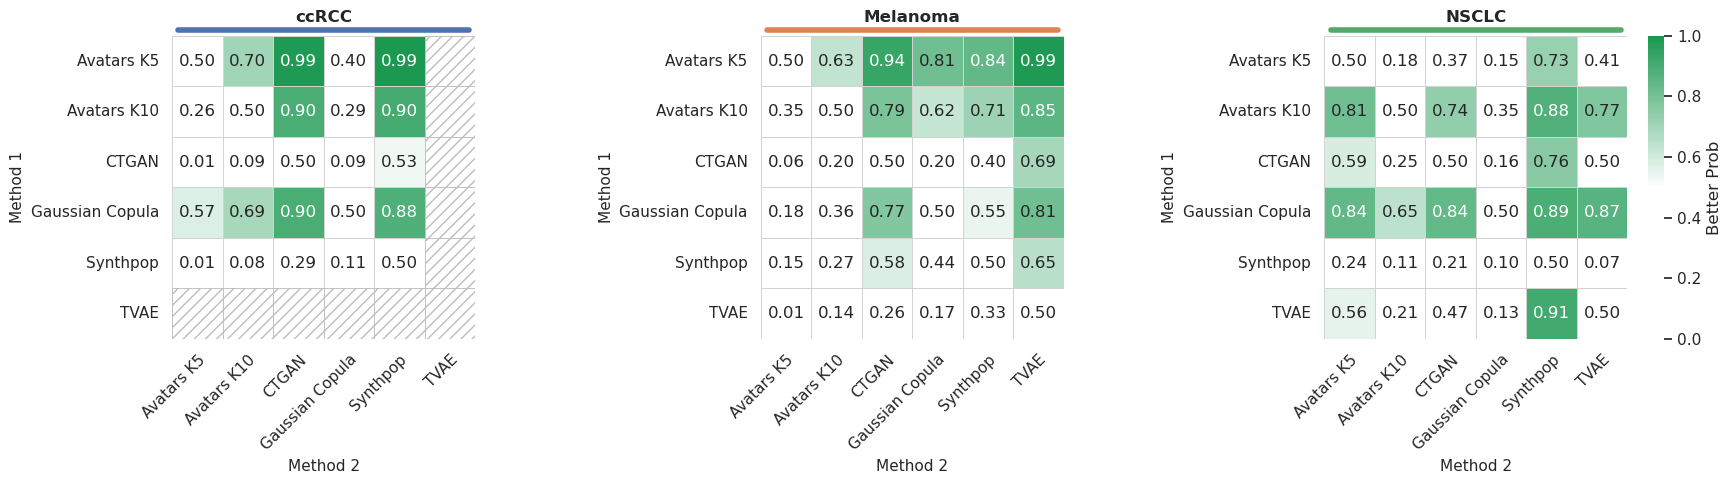

In [7]:
methods_order = ["Avatars K5", "Avatars K10", "CTGAN", "Gaussian Copula", "Synthpop", "TVAE"]
# methods_order_ccRCC 
# 1) Comparison dataframe cho 1 cancer
cc_df_ccRCC = build_baycomp_comparison_df(
    method_to_scores=Cancer_dict["ccRCC"],
    methods_order=methods_order,
    rope=0.01,
)
cc_df_Melanoma = build_baycomp_comparison_df(
    method_to_scores=Cancer_dict["Melanoma"],
    methods_order=methods_order,
    rope=0.01,
)
cc_df_NSCLC = build_baycomp_comparison_df(
    method_to_scores=Cancer_dict["NSCLC"],
    methods_order=methods_order,
    rope=0.01,
)
# print(cc_df.head())

# 2) 3 heatmaps (ccRCC, Melanoma, NSCLC)
fig_b, axes, mats_by_cancer, comp_by_cancer = plot_pbetter_heatmap_grid(
    cancer_to_method_scores=Cancer_dict,
    cancers_order=["ccRCC", "Melanoma", "NSCLC"],
    methods_order=methods_order,
    rope=0.01,
    value_col="Better Prob",   # hoặc "Equivalent Prob"
    figsize=(18, 5),
    annot=True,
    fmt=".2f",
    fontsize=11,
)
fig_b.savefig("PanelB.png", dpi=300, bbox_inches="tight")
fig_b.savefig("PanelB.pdf", bbox_inches="tight", facecolor="white")
cc_df_ccRCC.to_csv('Bayesian_estimation_ccRCC.csv')
cc_df_Melanoma.to_csv('Bayesian_estimation_Melanoma.csv')
cc_df_NSCLC.to_csv('Bayesian_estimation_NSCLC.csv')

## Spearman

In [9]:
seeds = [42,0,1,2,3]
cancers = ["ccRCC", "Melanoma","NSCLC"]
algo = ["Avatars K5", "Avatars K10", "CTGAN", "Gaussian Copula", "Synthpop"]
Cancer_spearman_dict = {}
for cancer in cancers:
    score_dict_spearman = {}
    for seed in seeds:
        if cancer == 'ccRCC':
            spearman_seed = pd.read_csv(f"../ccRCC/NarrowUtility/CellDecovo/ResultsDA_cibersortx/Seed_{seed}/Spearman_{seed}.csv")
            algo = ["Avatars K5", "Avatars K10", "CTGAN", "Gaussian Copula", "Synthpop"]
        if cancer == 'Melanoma':
            spearman_seed = pd.read_csv(f"../Melanoma/NarrowUtility/CellDecovo/ResultsDA/Seed_{seed}/Spearman_{seed}.csv")
            algo = ["Avatars K5", "Avatars K10", "CTGAN", "Gaussian Copula", "Synthpop", 'TVAE']
        if cancer == 'NSCLC':
            spearman_seed = pd.read_csv(f"../NSCLC/NarrowUtility/CellDeco/ResultsDA_cibersortx/Seed_{seed}/Spearman_{seed}.csv")
            algo = ["Avatars K5", "Avatars K10", "CTGAN", "Gaussian Copula", "Synthpop", "TVAE"]
        # scores = spearman_seed['Spearman_rho'].values.tolist()
        # Chuyển các giá trị âm thành 0 ngay trong Series
        scores = spearman_seed['Spearman_rho'].clip(lower=0).values.tolist()
        
        score_dict_spearman[seed] = scores
    df_cancer = pd.DataFrame(score_dict_spearman, index = algo).T
    Cancer_spearman_dict[cancer] = df_cancer

/tmp/ipykernel_1109633/2226866363.py:229: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1109633/2226866363.py:242: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_by_method = df_long.groupby("Method")[value_name].mean().reindex(list(methods_order))
/tmp/ipykernel_1109633/2226866363.py:229: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1109633/2226866363.py:242: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version 

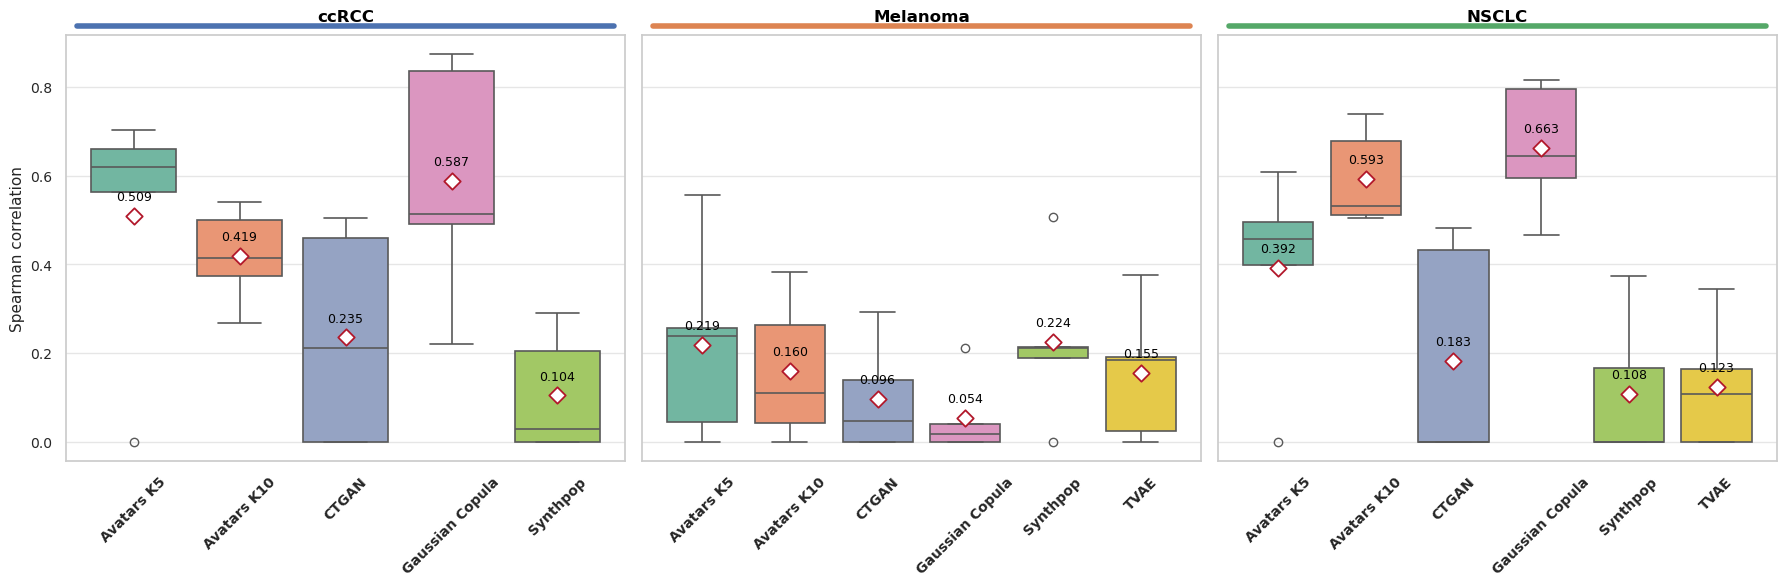

In [10]:
fig_c, axes, mean_by_cancer = plot_boxplot_grid_by_cancer(
    cancer_to_method_scores=Cancer_spearman_dict,
    value_name="Spearman correlation",  
    methods_order=algo, 
    palette=DATASET_COLORS, 
    figsize=(18, 6),         
    fontsize=11,
    annotate_mean=True,    
    show=True,
)

fig_c.savefig("panelC.png", dpi=300, bbox_inches="tight", facecolor="white")
fig_c.savefig("panelC.pdf", bbox_inches="tight", facecolor="white")

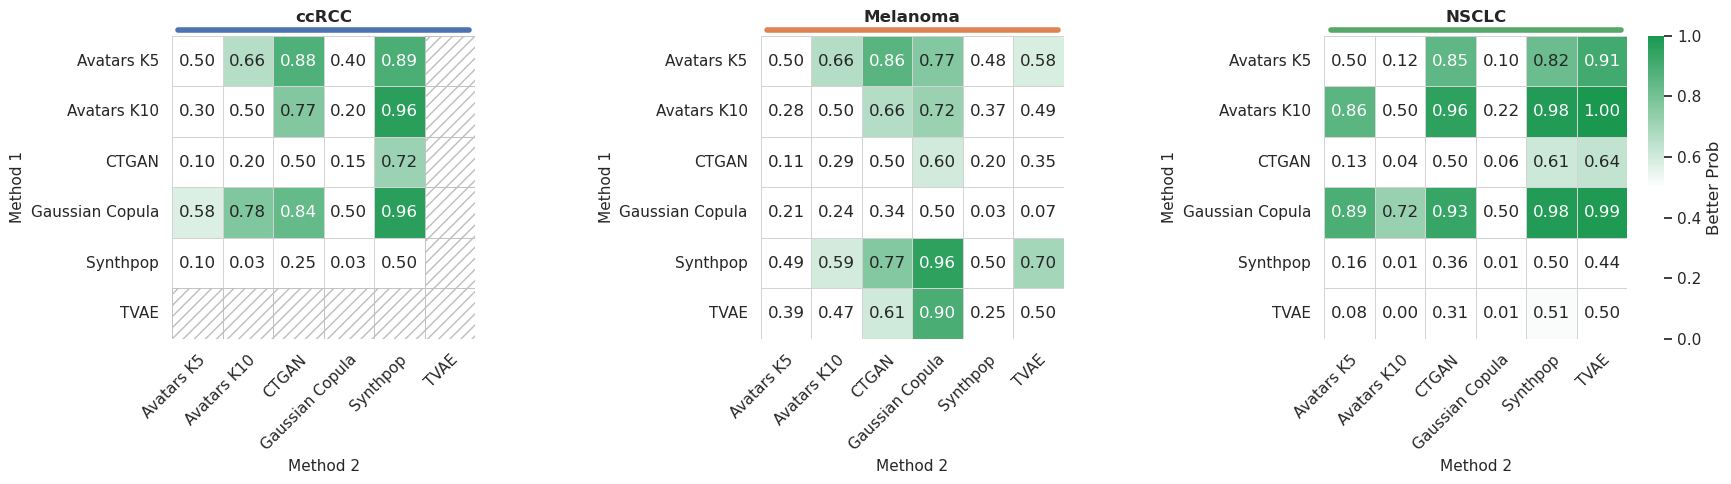

In [11]:
methods_order = ["Avatars K5", "Avatars K10", "CTGAN", "Gaussian Copula", "Synthpop", "TVAE"]
# methods_order_ccRCC 
# 1) Comparison dataframe cho 1 cancer
cc_df_ccRCC = build_baycomp_comparison_df(
    method_to_scores=Cancer_spearman_dict["ccRCC"],
    methods_order=methods_order,
    rope=0.01,
)
cc_df_Melanoma = build_baycomp_comparison_df(
    method_to_scores=Cancer_spearman_dict["Melanoma"],
    methods_order=methods_order,
    rope=0.01,
)
cc_df_NSCLC = build_baycomp_comparison_df(
    method_to_scores=Cancer_spearman_dict["NSCLC"],
    methods_order=methods_order,
    rope=0.01,
)
# print(cc_df.head())

# 2) 3 heatmaps (ccRCC, Melanoma, NSCLC)
fig_d, axes, mats_by_cancer, comp_by_cancer = plot_pbetter_heatmap_grid(
    cancer_to_method_scores=Cancer_spearman_dict,
    cancers_order=["ccRCC", "Melanoma", "NSCLC"],
    methods_order=methods_order,
    rope=0.01,
    # seed=42,
    value_col="Better Prob",   # hoặc "Equivalent Prob"
    figsize=(18, 5),
    annot=True,
    fmt=".2f",
    fontsize=11,
)
fig_d.savefig("PanelD_Spearman.png", dpi=300, bbox_inches="tight")
fig_d.savefig("PanelD_Spearman.pdf", bbox_inches="tight", facecolor="white")
cc_df_ccRCC.to_csv('SpearmanBayesian_estimation_ccRCC.csv')
cc_df_Melanoma.to_csv('SpearmanBayesian_estimation_Melanoma.csv')
cc_df_NSCLC.to_csv('SpearmanBayesian_estimation_NSCLC.csv')